#EDA Dataset Penguins

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving penguins.csv to penguins.csv


In [3]:
df = pd.read_csv("penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
df.shape

(344, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [6]:
df.replace("NA", np.nan, inplace=True)

In [7]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


In [8]:
df = df.dropna()

In [9]:
df["bill_length_mm"] = df["bill_length_mm"].astype(float)
df["bill_depth_mm"] = df["bill_depth_mm"].astype(float)
df["flipper_length_mm"] = df["flipper_length_mm"].astype(float)
df["body_mass_g"] = df["body_mass_g"].astype(float)

In [10]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


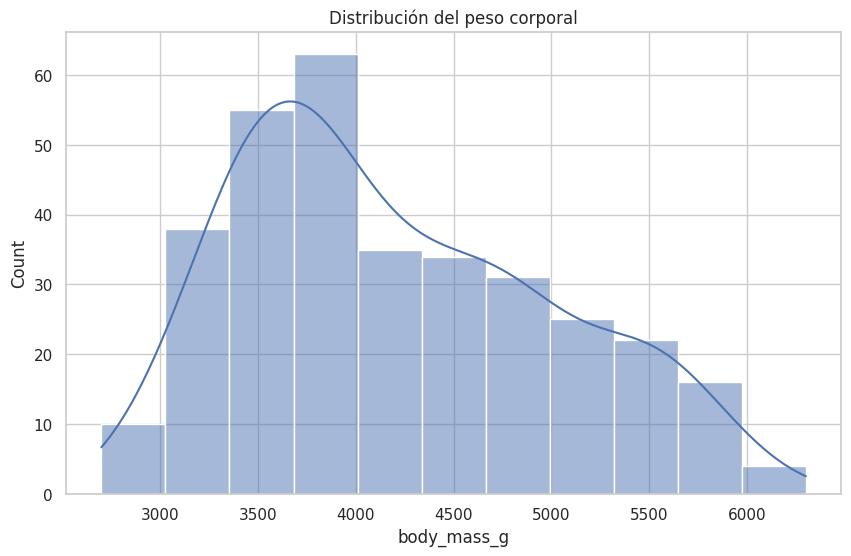

In [11]:
sns.histplot(df["body_mass_g"], kde=True)
plt.title("Distribución del peso corporal")
plt.show()

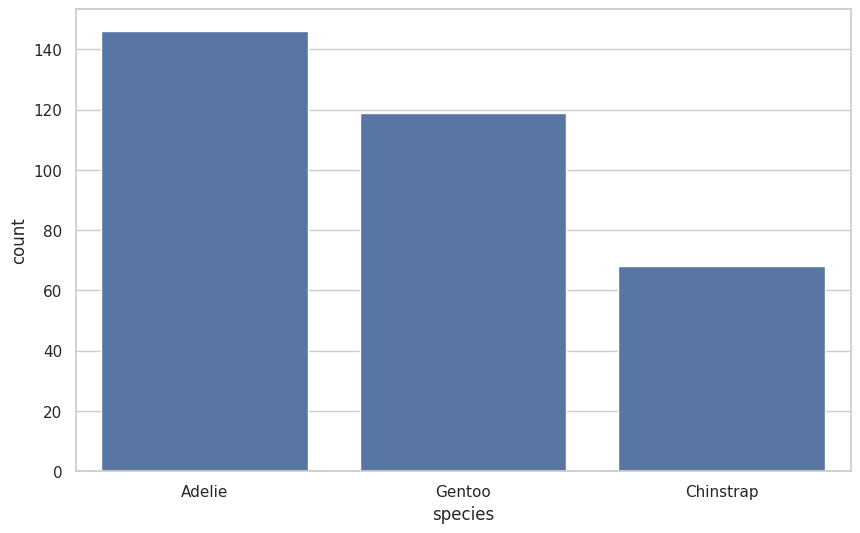

In [12]:
sns.countplot(x="species", data=df)
plt.show()

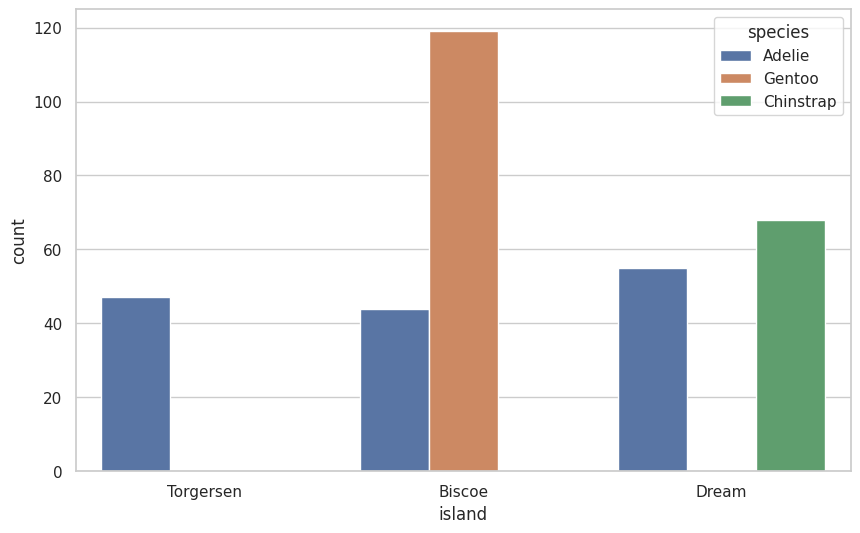

In [13]:
sns.countplot(x="island", hue="species", data=df)
plt.show()

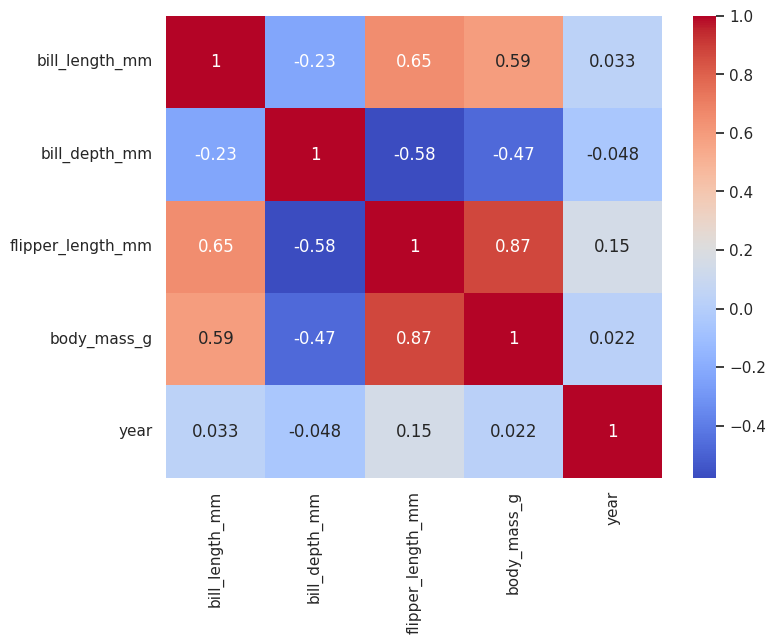

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

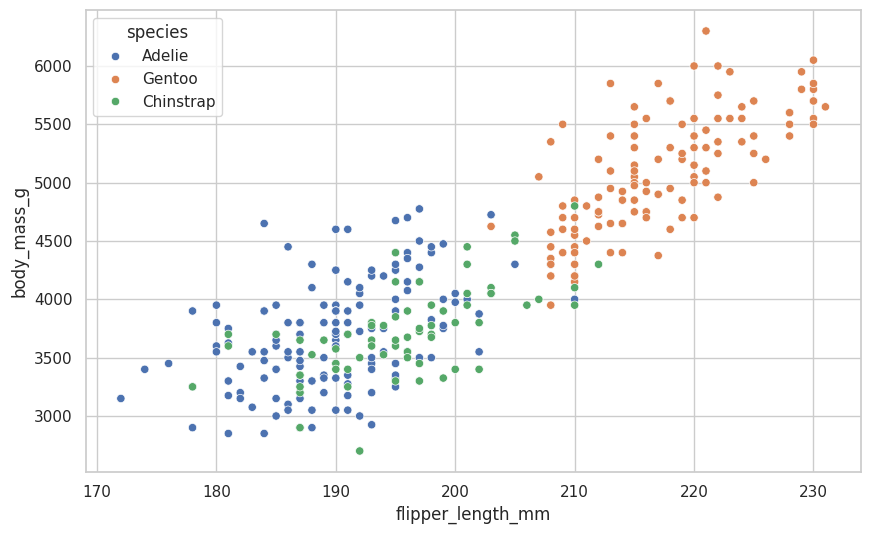

In [15]:
sns.scatterplot(
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    data=df
)
plt.show()

#Regresion Lineal para Penguins

predecir el peso del pinguino

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
X = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm"
]]

y = df["body_mass_g"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 142415.5280154186
R2: 0.7617950769145994


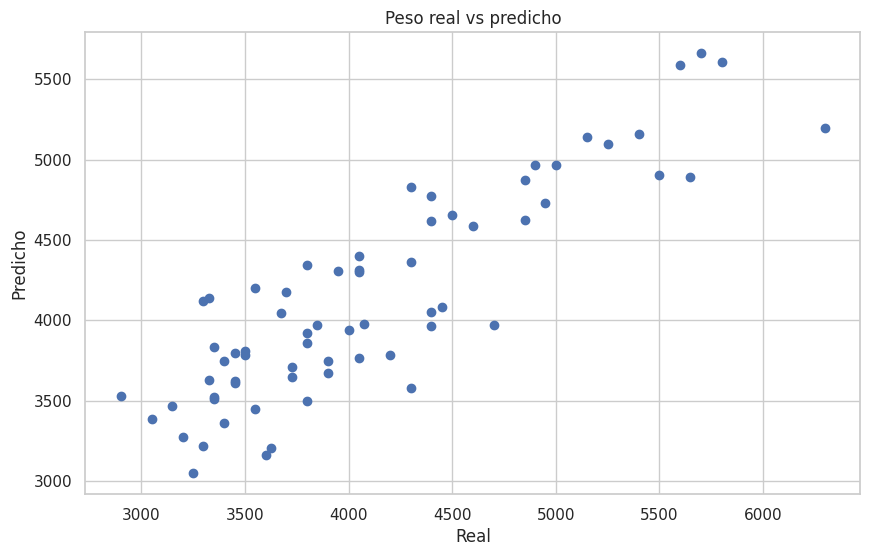

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Peso real vs predicho")
plt.show()

#Regresion logistica

se clasifica el sexo del pinguino

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [23]:
df["sex"] = df["sex"].map({
    "male": 1,
    "female": 0
})

In [25]:
X = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

y = df["sex"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
y_pred = log_model.predict(X_test)

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8955223880597015
[[31  5]
 [ 2 29]]


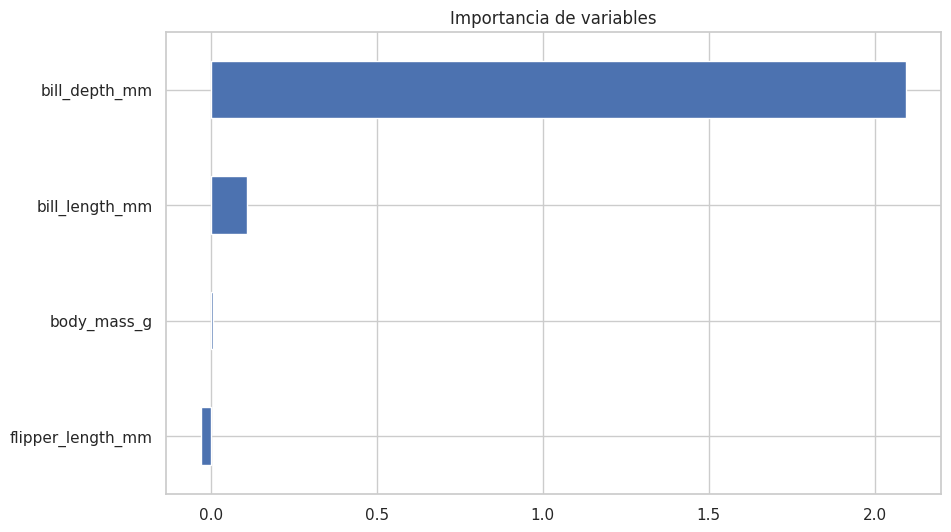

In [30]:
pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values().plot(kind="barh")

plt.title("Importancia de variables")
plt.show()